<a href="https://colab.research.google.com/github/kasiaqn/bee-audio-classifier/blob/main/BeehiveProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kasiaqn/bee-audio-classifier/blob/main/BeehiveProject.ipynb)

In [2]:
from google.colab import drive
import os

In [7]:
# Konfiguracja
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/BeehiveProject'
DRIVE_DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
# Połączenie z Kaggle
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

import kaggle

In [8]:
# Pobranie danych
DATASET_ID = "annajyang/beehive-sounds"
zip_on_drive = os.path.join(DRIVE_DATA_DIR, "beehive-sounds.zip")

if not os.path.exists(zip_on_drive):
    print("Pobieranie datasetu na Dysk Google.")
    !kaggle datasets download -d {DATASET_ID} -p {DRIVE_DATA_DIR}
    print("Pobieranie zakończone :)")
else:
    print("Plik .zip już jest na Twoim Dysku Google :)")

Plik .zip już jest na Twoim Dysku Google :)


In [9]:
# Kopiowanie z Dysku Google na lokalny dysk sesji + rozpakowywanie
import shutil

local_zip = "/content/temp_beehive.zip"
LOCAL_DATA_PATH = "/content/dataset_local"

if not os.path.exists(local_zip):
    print("Kopiowanie plików na dysk sesji")
    shutil.copy(zip_on_drive, local_zip)

if not os.path.exists(LOCAL_DATA_PATH):
    print("Rozpakowywanie")
    !unzip -q {local_zip} -d {LOCAL_DATA_PATH}
    os.remove(local_zip)
    print("Gotowe, dane są w folderze /content/dataset_local")

Kopiowanie plików na dysk sesji
Rozpakowywanie
Gotowe, dane są w folderze /content/dataset_local


Przykładowe pliki:
['all_data_updated.csv', 'sound_files']


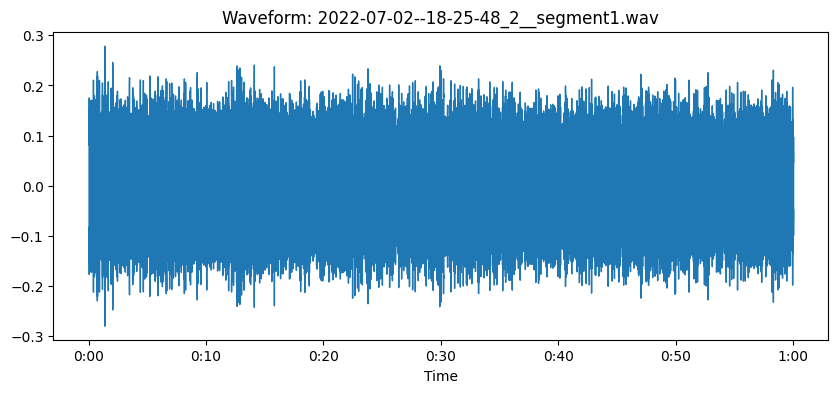

In [8]:
# Wyświetlanie przykładowej fali dźwiękowej
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Przykładowy plik:")

all_wavs = []
for root, dirs, files in os.walk(LOCAL_DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            all_wavs.append(os.path.join(root, file))

sample_file = all_wavs[0]
y, sr = librosa.load(sample_file, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {os.path.basename(sample_file)}")
plt.show()